In [1]:
# DMFNet_BrainTumor_Classification.ipynb

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import transforms, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tqdm import tqdm
from PIL import Image


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader

In [3]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
# Original data paths
ORIGINAL_BASE_DIR = r"C:\Users\manav\Documents\lighTumorNet\Brain_Tumor_MRI_Dataset"
ORIGINAL_TRAIN_DIR = os.path.join(ORIGINAL_BASE_DIR, "Training")
ORIGINAL_TEST_DIR = os.path.join(ORIGINAL_BASE_DIR, "Testing")

# Create new directory for preprocessed data (sibling to original base)
PROCESSED_BASE_DIR = os.path.join(os.path.dirname(ORIGINAL_BASE_DIR), "Processed_Brain_Tumor_MRI_Dataset")
PROCESSED_TRAIN_DIR = os.path.join(PROCESSED_BASE_DIR, "Training")
PROCESSED_TEST_DIR = os.path.join(PROCESSED_BASE_DIR, "Testing")

# Image parameters
IMG_HEIGHT = 150
IMG_WIDTH = 150
CHANNELS = 3
BATCH_SIZE = 32

# Create processed directories if they don't exist
os.makedirs(PROCESSED_BASE_DIR, exist_ok=True)
os.makedirs(PROCESSED_TRAIN_DIR, exist_ok=True)
os.makedirs(PROCESSED_TEST_DIR, exist_ok=True)

# Class names
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Create class directories in processed folders
for class_name in CLASS_NAMES:
    os.makedirs(os.path.join(PROCESSED_TRAIN_DIR, class_name), exist_ok=True)
    os.makedirs(os.path.join(PROCESSED_TEST_DIR, class_name), exist_ok=True)

print("Directory structure created successfully!")

Directory structure created successfully!


In [5]:
train_transform = transforms.Compose([
    transforms.Lambda(lambda img: Image.fromarray(img) if isinstance(img, np.ndarray) else img),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.002,0.002), shear=10),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Lambda(lambda img: Image.fromarray(img) if isinstance(img, np.ndarray) else img),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

In [6]:
try:
    BrainTumorDataset  # if defined earlier
except NameError:
    import cv2
    class BrainTumorDataset(torch.utils.data.Dataset):
        def __init__(self, root_dir, transform=None):
            self.root_dir = root_dir
            self.transform = transform
            self.classes = CLASS_NAMES
            self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
            self.samples = []
            for class_name in self.classes:
                class_dir = os.path.join(root_dir, class_name)
                if os.path.exists(class_dir):
                    for img_name in os.listdir(class_dir):
                        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                            self.samples.append((os.path.join(class_dir, img_name), self.class_to_idx[class_name]))
        def __len__(self):
            return len(self.samples)
        def __getitem__(self, idx):
            img_path, label = self.samples[idx]
            image = cv2.imread(img_path)
            if image is None:
                raise ValueError(f"Failed to read image at {img_path}")
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            if self.transform:
                image = self.transform(image)
            return image, int(label)


In [7]:
_num_workers = 0 if os.name == 'nt' else min(4, (os.cpu_count() or 1))
train_dataset = BrainTumorDataset(root_dir=PROCESSED_TRAIN_DIR, transform=train_transform)
test_dataset  = BrainTumorDataset(root_dir=PROCESSED_TEST_DIR, transform=test_transform)

# Pre-check: raise a clear error if datasets are empty (prevents RandomSampler num_samples=0)
if len(train_dataset) == 0:
    raise RuntimeError(f"No training samples found in '{PROCESSED_TRAIN_DIR}'. Check the path and that class subfolders exist. cwd={os.getcwd()}")
if len(test_dataset) == 0:
    raise RuntimeError(f"No test samples found in '{PROCESSED_TEST_DIR}'. Check the path and that class subfolders exist. cwd={os.getcwd()}")

# Create data loaders (safe settings for Windows / notebooks)
pin_mem = True if torch.cuda.is_available() else False
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=_num_workers, pin_memory=pin_mem)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=_num_workers, pin_memory=pin_mem)

print(f"Samples - Train: {len(train_dataset)} | Test: {len(test_dataset)} | Classes: {len(CLASS_NAMES)}")


Samples - Train: 5712 | Test: 1311 | Classes: 4


In [8]:
class DepthAttentionModule(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        mid = max(in_channels // reduction, 4)
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, mid, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(mid, in_channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class DMFNet(nn.Module):
    def __init__(self, num_classes=4, backbone="mobilenetv3", shallow_layer_index=3):
        """
        backbone: "mobilenetv3" or "efficientnet_b0"
        shallow_layer_index: index at which to take the 'shallow' feature map from backbone.features
        """
        super().__init__()
        # load backbone
        if backbone == "mobilenetv3":
            base = models.mobilenet_v3_large(pretrained=True)
            backbone_features = base.features  # nn.Sequential
        elif backbone == "efficientnet_b0":
            base = models.efficientnet_b0(pretrained=True)
            backbone_features = base.features
        else:
            raise ValueError("Unsupported backbone")
        self.backbone_name = backbone
        self.backbone_features = backbone_features

        # store shallow idx for forward and create an explicit shallow feature nn.Sequential
        # TorchScript doesn't allow slicing a Sequential at runtime, so build the shallow module here
        self.shallow_layer_index = shallow_layer_index
        modules = list(self.backbone_features.children())
        # guard shallow index
        if not isinstance(self.shallow_layer_index, int) or self.shallow_layer_index < 0:
            raise ValueError("shallow_layer_index must be a non-negative int")
        shallow_modules = modules[:self.shallow_layer_index]
        self.shallow_features = nn.Sequential(*shallow_modules) if len(shallow_modules) > 0 else nn.Identity()
        self.deep_features = self.backbone_features

        # probe shapes by running a dummy input through the explicit modules
        dummy = torch.randn(1, 3, 224, 224)
        self.backbone_features.eval()
        with torch.no_grad():
            shallow_out = self.shallow_features(dummy)
            deep_out = self.deep_features(dummy)
        shallow_ch = shallow_out.shape[1]
        deep_ch = deep_out.shape[1]

        # Depth Attention on deep features
        self.depth_att = DepthAttentionModule(deep_ch, reduction=16)

        # channel reducers -> to fixed 128 each (keeps head small)
        self.reduce_shallow = nn.Conv2d(shallow_ch, 128, kernel_size=1)
        self.reduce_deep = nn.Conv2d(deep_ch, 128, kernel_size=1)

        # fusion conv
        self.fusion_conv = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.15)
        )

        # classifier: global pool + compact FC
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35),
            nn.Linear(256, num_classes)
        )

        # (self.shallow_layer_index already set above)

        # initialize small layers
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        # shallow features (use pre-built module to keep TorchScript happy)
        shallow_feat = self.shallow_features(x)
        # deep features
        deep_feat = self.deep_features(x)

        # apply depth attention
        deep_feat = self.depth_att(deep_feat)

        # resize shallow -> deep spatial dims
        if shallow_feat.shape[2:] != deep_feat.shape[2:]:
            shallow_feat = nn.functional.interpolate(shallow_feat, size=deep_feat.shape[2:], mode='bilinear', align_corners=False)

        # reduce channels
        s = self.reduce_shallow(shallow_feat)
        d = self.reduce_deep(deep_feat)

        fused = torch.cat([s, d], dim=1)  # (B, 256, H, W)
        fused = self.fusion_conv(fused)

        out = self.classifier(fused)
        return out


In [9]:
model = DMFNet(num_classes=len(CLASS_NAMES), backbone="mobilenetv3", shallow_layer_index=3).to(device)
print(model)

c:\Users\manav\miniconda3\envs\efficientnet\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\manav\miniconda3\envs\efficientnet\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


DMFNet(
  (backbone_features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1)

In [10]:
# ---------- training setup ----------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4, verbose=True)

# ---------- training loop ----------
EPOCHS = 25
best_val_loss = float('inf')
patience = 6
patience_counter = 0

train_losses, train_accs = [], []
val_losses, val_accs = [], []

if len(train_dataset) == 0 or len(test_dataset) == 0:
    raise RuntimeError("Datasets empty: check processed dirs and preprocessing cells")

print("Starting DMFNet training...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for imgs, labels in tqdm(train_loader, desc=f"Train Epoch {epoch+1}/{EPOCHS}"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # validation
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    all_outputs = []
    all_labels = []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, preds = outputs.max(1)
            val_total += labels.size(0)
            val_correct += preds.eq(labels).sum().item()
            all_outputs.append(outputs.cpu())
            all_labels.append(labels.cpu())

    val_loss = val_running_loss / len(test_loader)
    val_acc = 100. * val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # scheduler
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # early stopping & best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "dmfnet_best.pth")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

print("Training finished. Best val loss:", best_val_loss)


c:\Users\manav\miniconda3\envs\efficientnet\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Starting DMFNet training...


Train Epoch 1/25: 100%|██████████| 179/179 [00:51<00:00,  3.47it/s]



Epoch 1/25 | Train Loss: 1.0893 | Train Acc: 56.07% | Val Loss: 2.6324 | Val Acc: 30.89%


Train Epoch 2/25: 100%|██████████| 179/179 [00:49<00:00,  3.64it/s]



...

Epoch 23/25 | Train Loss: 0.1097 | Train Acc: 95.94% | Val Loss: 0.0870 | Val Acc: 96.64%


Train Epoch 24/25: 100%|██████████| 179/179 [00:48<00:00,  3.70it/s]



Epoch 24/25 | Train Loss: 0.1014 | Train Acc: 96.38% | Val Loss: 0.1193 | Val Acc: 96.34%


Train Epoch 25/25: 100%|██████████| 179/179 [00:48<00:00,  3.71it/s]



Epoch 25/25 | Train Loss: 0.0876 | Train Acc: 97.04% | Val Loss: 0.0829 | Val Acc: 96.34%
Training finished. Best val loss: 0.0829337064181057


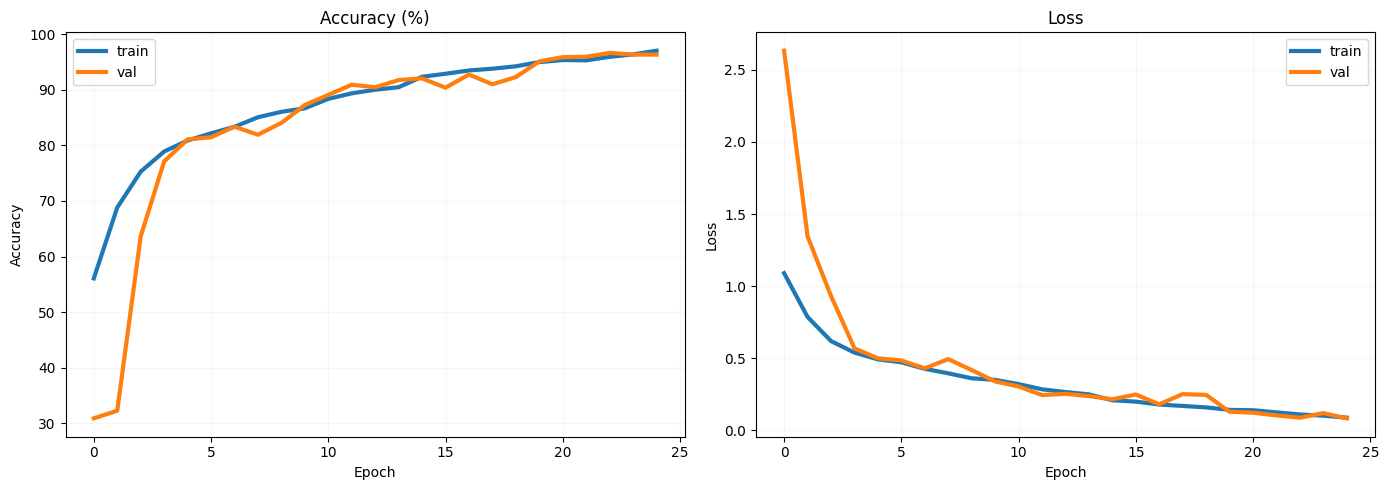

In [11]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(train_accs, label='train', linewidth=3)
plt.plot(val_accs, label='val', linewidth=3)
plt.title("Accuracy (%)"); plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(alpha=0.1)
plt.subplot(1,2,2)
plt.plot(train_losses, label='train', linewidth=3)
plt.plot(val_losses, label='val', linewidth=3)
plt.title("Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(alpha=0.1)
plt.tight_layout(); plt.show()


C:\Users\manav\AppData\Local\Temp\ipykernel_11652\380716144.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("dmfnet_best.pth", map_locat

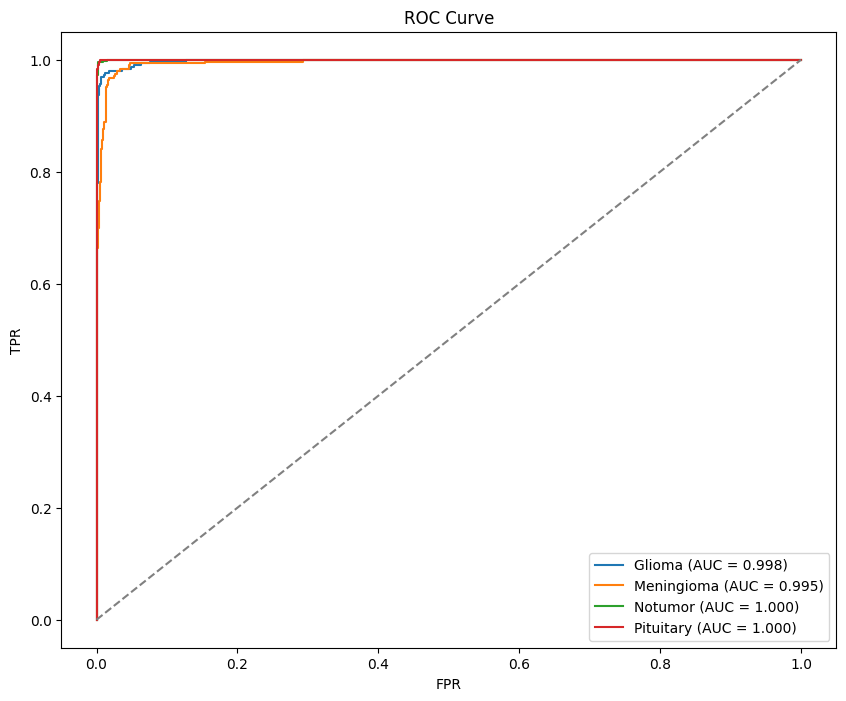

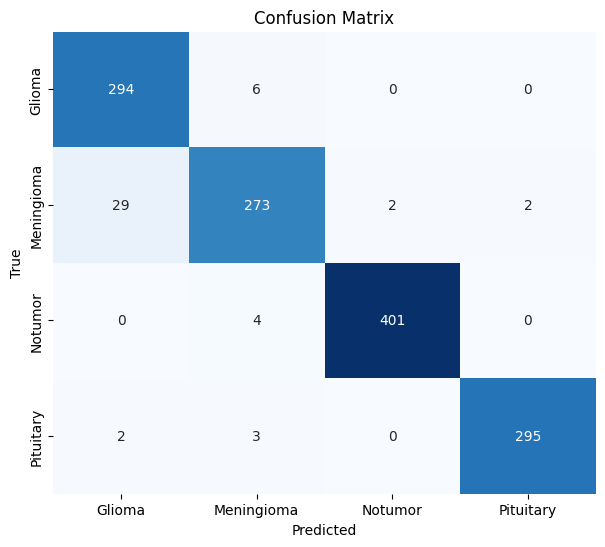

Classification Report:

              precision    recall  f1-score   support

      Glioma   0.904615  0.980000  0.940800       300
  Meningioma   0.954545  0.892157  0.922297       306
     Notumor   0.995037  0.990123  0.992574       405
   Pituitary   0.993266  0.983333  0.988275       300

    accuracy                       0.963387      1311
   macro avg   0.961866  0.961403  0.960987      1311
weighted avg   0.964489  0.963387  0.963339      1311



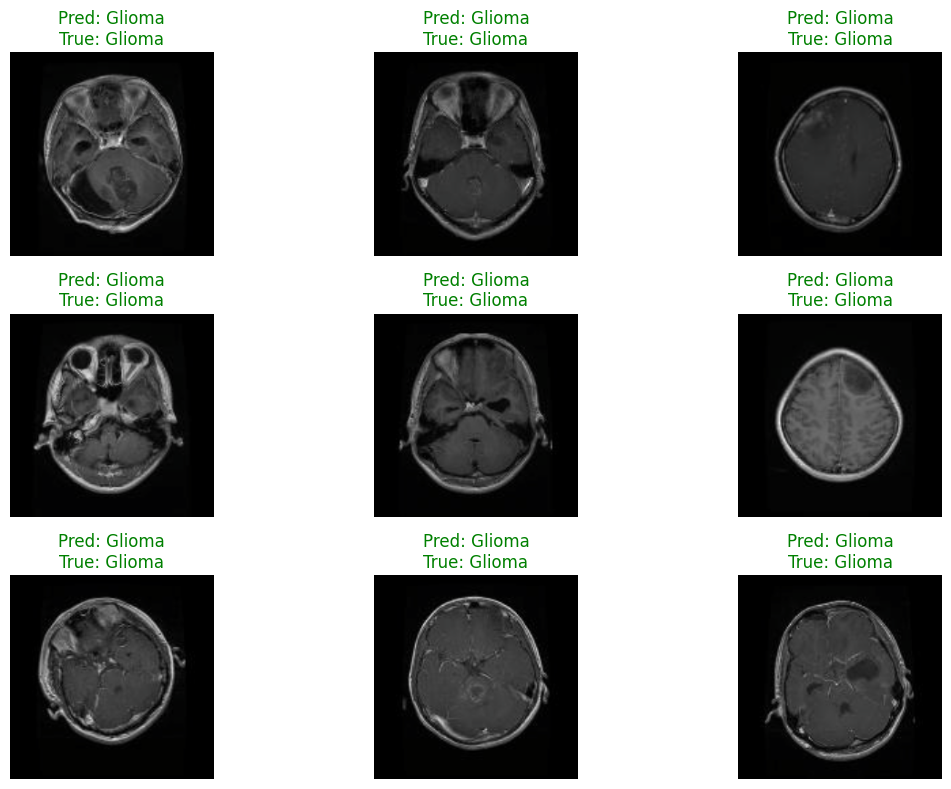

In [12]:
model.load_state_dict(torch.load("dmfnet_best.pth", map_location=device))
model.eval()

all_probs = []
all_preds = []
all_true = []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1).cpu().numpy()
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds)
        all_true.extend(labels.numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_true = np.array(all_true)

# ROC curves & AUC
plt.figure(figsize=(10,8))
y_true_bin = label_binarize(all_true, classes=np.arange(len(CLASS_NAMES)))
for i, cname in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cname.title()} (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curve"); plt.legend(); plt.show()

# confusion matrix
cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=[n.title() for n in CLASS_NAMES],
            yticklabels=[n.title() for n in CLASS_NAMES])
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix"); plt.show()

# classification report
print("Classification Report:\n")
print(classification_report(all_true, all_preds, target_names=[n.title() for n in CLASS_NAMES], digits=6))

# sample predictions helper
def plot_sample_predictions(model, loader, num_samples=9, figsize=(12,8)):
    model.eval()
    imgs_show, preds_show, labels_show = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            outputs = model(imgs.to(device))
            _, preds = outputs.max(1)
            imgs_show.extend(imgs.cpu())
            preds_show.extend(preds.cpu())
            labels_show.extend(labels)
            if len(imgs_show) >= num_samples:
                break
    imgs_show = imgs_show[:num_samples]
    preds_show = preds_show[:num_samples]
    labels_show = labels_show[:num_samples]

    plt.figure(figsize=figsize)
    for i, img in enumerate(imgs_show):
        img_np = img.permute(1,2,0).numpy()
        img_np = img_np * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
        img_np = np.clip(img_np, 0, 1)
        plt.subplot(3,3,i+1)
        plt.imshow(img_np)
        color = "green" if preds_show[i]==labels_show[i] else "red"
        plt.title(f"Pred: {CLASS_NAMES[preds_show[i]].title()}\nTrue: {CLASS_NAMES[labels_show[i]].title()}", color=color)
        plt.axis("off")
    plt.tight_layout(); plt.show()

plot_sample_predictions(model, test_loader, num_samples=9)


In [13]:
# Dynamic quantization reduces FC/Linear sizes dramatically; good for CPU deployment.
quantized = torch.quantization.quantize_dynamic(model, {nn.Linear}, dtype=torch.qint8)
torch.save(quantized.state_dict(), "dmfnet_quantized.pth")
size_mb = os.path.getsize("dmfnet_quantized.pth") / 1e6
print(f"Quantized model size: {size_mb:.3f} MB")

# TorchScript export for deployment (scripted quantized model)
try:
    scripted = torch.jit.script(quantized)
    scripted.save("dmfnet_quantized_scripted.pt")
    print("TorchScript saved: dmfnet_quantized_scripted.pt")
except Exception as e:
    print("TorchScript scripting failed:", e)

# Print final size and quick summary
print("Final summary:")
print(f"Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}")
print(f"Classes: {CLASS_NAMES}")
print(f"Quantized weights file size (MB): {size_mb:.3f}")


Quantized model size: 15.216 MB
TorchScript scripting failed: false INTERNAL ASSERT FAILED at "C:\\cb\\pytorch_1000000000000\\work\\aten\\src\\ATen\\quantized\\Quantizer.cpp":445, please report a bug to PyTorch. cannot call qscheme on UnknownQuantizer
Final summary:
Train samples: 5712 | Test samples: 1311
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Quantized weights file size (MB): 15.216
TorchScript scripting failed: false INTERNAL ASSERT FAILED at "C:\\cb\\pytorch_1000000000000\\work\\aten\\src\\ATen\\quantized\\Quantizer.cpp":445, please report a bug to PyTorch. cannot call qscheme on UnknownQuantizer
Final summary:
Train samples: 5712 | Test samples: 1311
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Quantized weights file size (MB): 15.216
